### Downloading Dataset

In [2]:
# Downloading the dataset from the Met Museum's open access repository if not already present locally.
import os
import urllib.request

DATA_DIR = "../data"
FILE_PATH = os.path.join(DATA_DIR, "MetObjects.csv")

if not os.path.exists(FILE_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    url = "https://media.githubusercontent.com/media/metmuseum/openaccess/master/MetObjects.csv"
    print("Downloading MetObjects.csv")
    urllib.request.urlretrieve(url, FILE_PATH)
    print(f"File saved to {FILE_PATH}")
else:
    print(f"File already exists at {FILE_PATH}")

File already exists at ../data/MetObjects.csv


In [3]:
# List all files in the dataset 
print("\n── Files in dataset ──")
path = DATA_DIR
for f in os.listdir(path):
    full = os.path.join(path, f)
    size_mb = os.path.getsize(full) / (1024 ** 2)
    print(f"  {f}  ({size_mb:.2f} MB)")


── Files in dataset ──
  MetObjects.csv  (302.94 MB)


### Data Overview
Quick look at dtypes, memory footprint, and how much is missing per column.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main CSV
csv_path = os.path.join(path, "MetObjects.csv")
df = pd.read_csv(csv_path, low_memory=False)

In [5]:
# Basic overview
print(f"\n── Shape: {df.shape[0]:,} rows × {df.shape[1]} columns ──")
print("\n── Column names ──")
print(df.columns.tolist())

print("\n── First 5 rows ──")
display(df.head())

print("\n── Data types & null counts ──")
info = pd.DataFrame({
    "dtype":    df.dtypes,
    "nulls":    df.isna().sum(),
    "null_%":   (df.isna().mean() * 100).round(1),
    
})

# Arrange nulls by descending order
info = info.sort_values(by='nulls', ascending=False)

display(info)


── Shape: 484,956 rows × 54 columns ──

── Column names ──
['Object Number', 'Is Highlight', 'Is Timeline Work', 'Is Public Domain', 'Object ID', 'Gallery Number', 'Department', 'AccessionYear', 'Object Name', 'Title', 'Culture', 'Period', 'Dynasty', 'Reign', 'Portfolio', 'Constituent ID', 'Artist Role', 'Artist Prefix', 'Artist Display Name', 'Artist Display Bio', 'Artist Suffix', 'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date', 'Artist End Date', 'Artist Gender', 'Artist ULAN URL', 'Artist Wikidata URL', 'Object Date', 'Object Begin Date', 'Object End Date', 'Medium', 'Dimensions', 'Credit Line', 'Geography Type', 'City', 'State', 'County', 'Country', 'Region', 'Subregion', 'Locale', 'Locus', 'Excavation', 'River', 'Classification', 'Rights and Reproduction', 'Link Resource', 'Object Wikidata URL', 'Metadata Date', 'Repository', 'Tags', 'Tags AAT URL', 'Tags Wikidata URL']

── First 5 rows ──


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN



── Data types & null counts ──


,dtype,nulls,null_%
Metadata Date,float64,484956,100.0
River,str,482864,99.6
State,str,482335,99.5
Locus,str,477438,98.4
County,str,476397,98.2
Reign,str,473720,97.7
Locale,str,469217,96.8
Excavation,str,468385,96.6
Subregion,str,462813,95.4
Dynasty,str,461755,95.2


### Missing Data
A lot of columns here are >75% null

In [6]:
# Data types
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
missing_df = missing_df.sort_values("Percent", ascending=False)
missing_df[missing_df["Percent"] > 0]

str        46
bool        3
int64       3
object      1
float64     1
Name: count, dtype: int64

Memory usage: 1215.0 MB


,Missing,Percent
Metadata Date,484956,100.00
River,482864,99.57
State,482335,99.46
Locus,477438,98.45
County,476397,98.24
Reign,473720,97.68
Locale,469217,96.75
Excavation,468385,96.58
Subregion,462813,95.43
Dynasty,461755,95.22


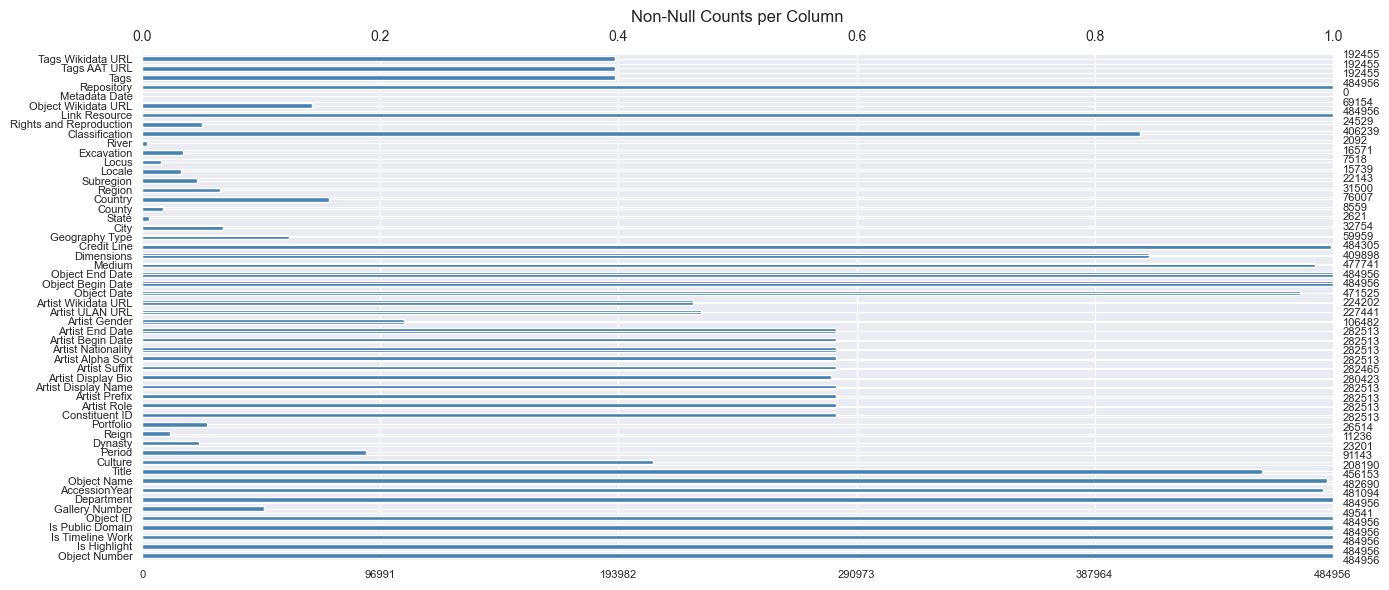

In [8]:
import missingno as msno
fig, ax = plt.subplots(figsize=(14, 6))
msno.bar(df, ax=ax, fontsize=8, color="steelblue")
plt.title("Non-Null Counts per Column")
plt.tight_layout()
# Missing data visualized
plt.show()

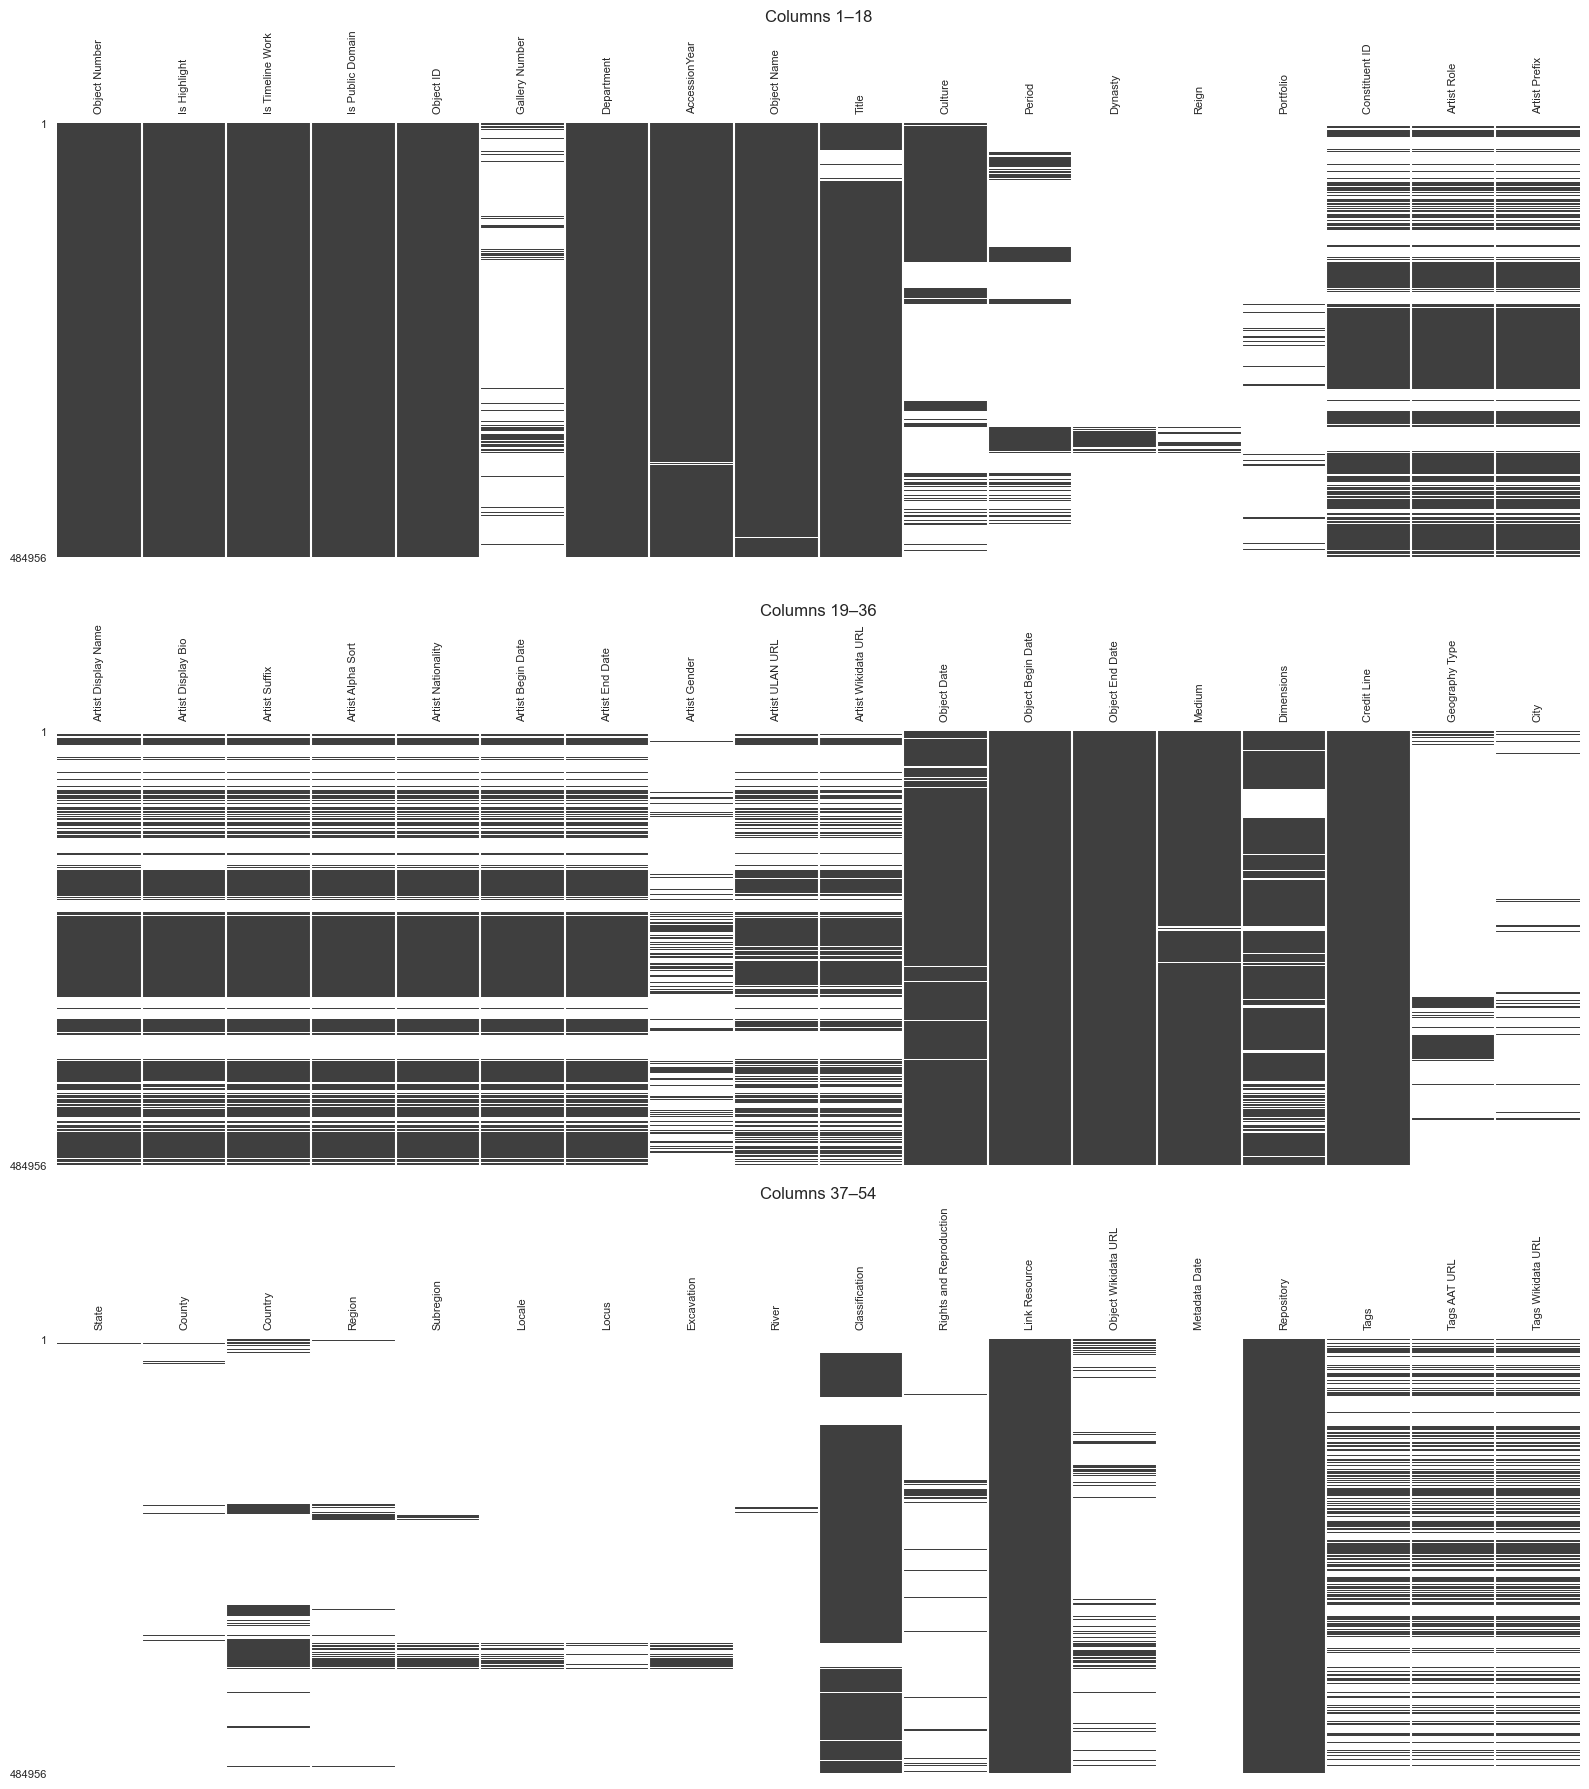

In [9]:
cols = df.columns.tolist()
third = len(cols) // 3

# splitting because the dataset has 54 columns, which is too many to visualize in one plot
splits = [cols[:third], cols[third:2*third], cols[2*third:]]
labels = ["Columns 1–18", "Columns 19–36", "Columns 37–54"]

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for ax, subset, label in zip(axes, splits, labels):
    msno.matrix(df[subset], ax=ax, fontsize=7, sparkline=False)
    ax.set_xticks(range(len(subset)))
    # setting x-labels for mapping
    ax.set_xticklabels(subset, rotation=90, ha="center", fontsize=8)
    ax.set_title(label)

plt.tight_layout()
plt.show()

#### Observations
- Core identifiers (Object Number, Object ID, Department, AccessionYear) are fully populated — no imputation needed for these.
- Period, Dynasty, Reign, and Portfolio are mostly empty — these only apply to specific object types (e.g., Egyptian, Chinese art).
- Artist fields (Name, Bio, Nationality, Begin/End Date) go missing together — if one is absent, they all tend to be.
- Geography columns (State, County, Country, Region, Subregion, Locale, Locus) show the same block pattern — present only for excavated or site-specific objects.
- Tags and their associated URLs are partially filled, likely added retroactively for a subset of the collection.

### Department Distribution


Number of departments: 19



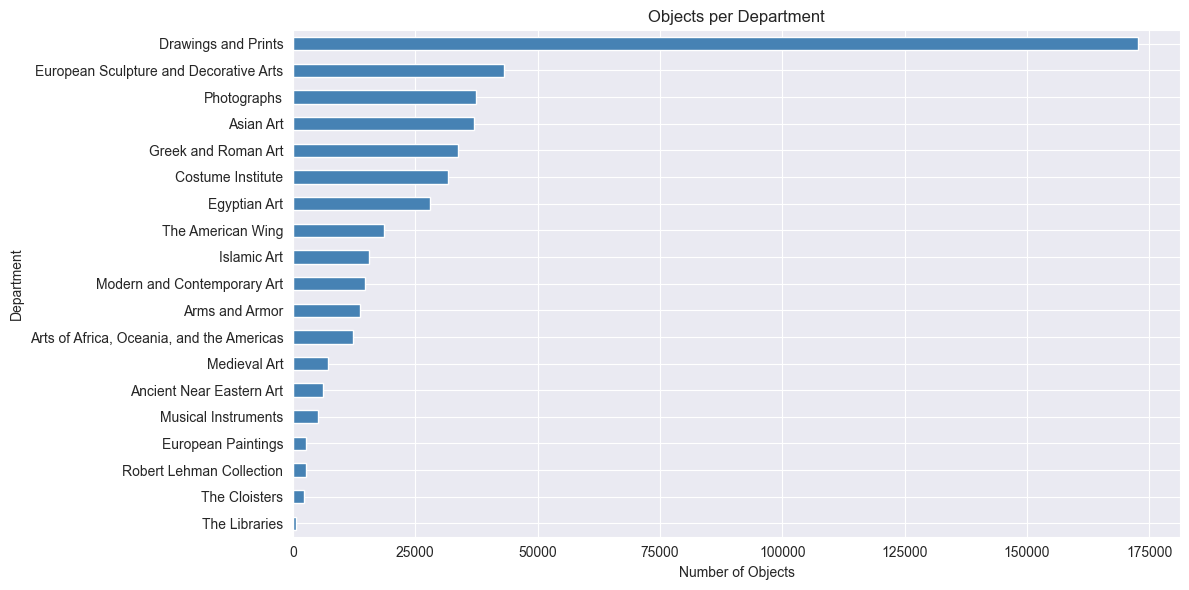

In [10]:
dept_counts = df["Department"].value_counts()
print(f"Number of departments: {dept_counts.shape[0]}\n")

fig, ax = plt.subplots(figsize=(12, 6))
dept_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of Objects")
ax.set_title("Objects per Department")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
#Key Columns - Columns we'll likely use as features
key_cols = ["Department", "Culture", "Period", "Medium", "Classification",
            "Object Name", "Object Begin Date", "Object End Date", "Tags"]

for col in key_cols:
    nunique = df[col].nunique()
    null_pct = df[col].isnull().mean() * 100
    print(f"{col:25s} | unique: {nunique:>6} | missing: {null_pct:.1f}%")

Department                | unique:     19 | missing: 0.0%
Culture                   | unique:   7313 | missing: 57.1%
Period                    | unique:   1891 | missing: 81.2%
Medium                    | unique:  65907 | missing: 1.5%
Classification            | unique:   1244 | missing: 16.2%
Object Name               | unique:  28631 | missing: 0.5%
Object Begin Date         | unique:   2076 | missing: 0.0%
Object End Date           | unique:   2041 | missing: 0.0%
Tags                      | unique:  44171 | missing: 60.3%


#### Target Class Imbalance
- Draws and Prints has 154K records while some departments have only a few hundred.
- Knowing the imbalance ratio upfront guides our choice of macro F1 over accuracy and whether resampling is needed.

In [12]:
dept_counts = df["Department"].value_counts()
dept_pct = (dept_counts / len(df) * 100).round(2)

imbalance_ratio = dept_counts.iloc[0] / dept_counts.iloc[-1]
print(f"Imbalance ratio (largest / smallest): {imbalance_ratio:.1f}x\n")

summary = pd.DataFrame({
    "Count": dept_counts,
    "Percent": dept_pct
})
display(summary)

Imbalance ratio (largest / smallest): 323.3x



,Count,Percent
Department,,
Drawings and Prints,172630,35.60
European Sculpture and Decorative Arts,43051,8.88
Photographs,37459,7.72
Asian Art,37000,7.63
Greek and Roman Art,33726,6.95
Costume Institute,31652,6.53
Egyptian Art,27969,5.77
The American Wing,18532,3.82
Islamic Art,15573,3.21


#### Object Date Distribution
- Object Begin Date spans 5000+ years of history. We check the temporal spread and flag any placeholder values (e.g. 0 or 9999) before using dates as features.


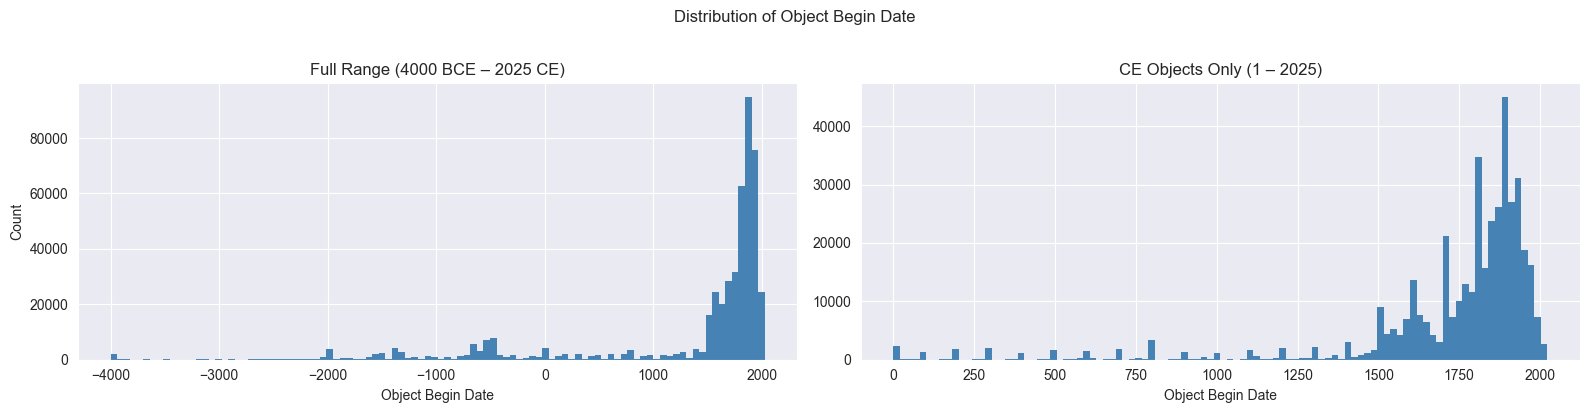

Min: -400000  |  Max: 5000
Objects before -4000: 2,074  (likely placeholder/junk values)
Objects after 2025:   2


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Full range (clipped to reasonable historical bounds)
clipped = df["Object Begin Date"].clip(lower=-4000, upper=2025)
clipped.hist(bins=100, ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_xlabel("Object Begin Date")
axes[0].set_ylabel("Count")
axes[0].set_title("Full Range (4000 BCE – 2025 CE)")

# Zoomed into CE period where most objects cluster
modern = df[df["Object Begin Date"].between(1, 2025)]["Object Begin Date"]
modern.hist(bins=100, ax=axes[1], color="steelblue", edgecolor="none")
axes[1].set_xlabel("Object Begin Date")
axes[1].set_title("CE Objects Only (1 – 2025)")

plt.suptitle("Distribution of Object Begin Date", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/object_begin_date_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Min: {df['Object Begin Date'].min()}  |  Max: {df['Object Begin Date'].max()}")
print(f"Objects before -4000: {(df['Object Begin Date'] < -4000).sum():,}  (likely placeholder/junk values)")
print(f"Objects after 2025:   {(df['Object Begin Date'] > 2025).sum():,}")